# 03 — Advanced Clustering Methods

This notebook expands on the K-Means baseline from `02_clustering.ipynb` by exploring three additional techniques:

- **Gaussian Mixture Models (GMM)** — probabilistic clustering with elliptical components
- **DBSCAN** — density-based clustering that discovers the number of clusters and detects outliers
- **PCA** — dimensionality reduction for visualization and comparison


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


Loading the dataset and applying the same preprocessing pipeline as in the previous notebooks (drop `CustomerID`, encode `Gender`, and scale all features) so this notebook can be run standalone.

In [4]:
DATA_PATH = "../data/raw/Mall_Customers.csv"
df = pd.read_csv(DATA_PATH)

df = df.drop(columns=['CustomerID'])

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

df_partial = df.drop(columns=['Age'])
df_partial = df_partial.drop(columns=['Gender'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_partial = scaler.fit_transform(df_partial)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


## Gaussian Mixture Models (GMM)

Unlike K-Means, which assigns each point to a single cluster, GMM treats clusters as **Gaussian distributions** and produces a **probability of membership** for each cluster. This soft assignment is especially useful for points near cluster boundaries.

Training a GMM with 5 components (same K as the K-Means model) on the reduced feature space (Income + Spending Score).

In [5]:

gmm = GaussianMixture(n_components=5, random_state=9)
labels_gmm = gmm.fit_predict(X_scaled_partial)

probabilities = gmm.predict_proba(X_scaled_partial)
df['GMM_Cluster'] = labels_gmm
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),GMM_Cluster
0,0,19,15,39,0
1,0,21,15,81,1
2,1,20,16,6,0
3,1,23,16,77,1
4,1,31,17,40,0


Text(0.5, 1.0, 'GMM Clustering of Customers')

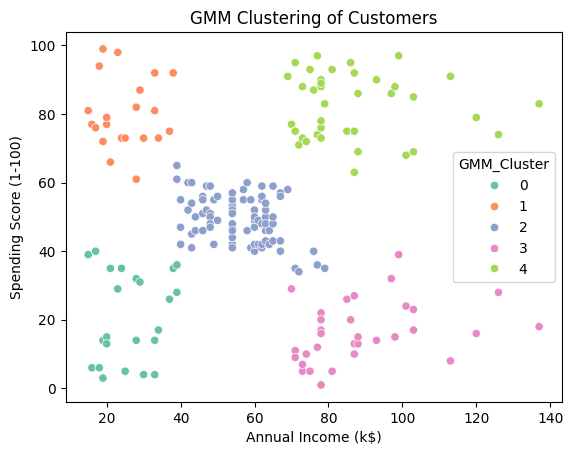

In [6]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='GMM_Cluster', data=df, palette='Set2')
plt.title('GMM Clustering of Customers')

In [7]:
max_probs = probabilities.max(axis=1)
df['max_prob'] = max_probs
print(df['max_prob'].head())
print()

print(df['max_prob'].describe())

0    0.999032
1    0.999790
2    0.999814
3    0.999694
4    0.998378
Name: max_prob, dtype: float64

count    200.000000
mean       0.982660
std        0.062703
min        0.502932
25%        0.996107
50%        0.999599
75%        0.999994
max        1.000000
Name: max_prob, dtype: float64


In [8]:
uncertain = df.nsmallest(10, 'max_prob')
print(uncertain[['Annual Income (k$)', 'Spending Score (1-100)', 'GMM_Cluster', 'max_prob']])


     Annual Income (k$)  Spending Score (1-100)  GMM_Cluster  max_prob
124                  70                      29            3  0.502932
48                   40                      42            2  0.611381
49                   40                      42            2  0.611381
27                   28                      61            1  0.674611
160                  79                      35            2  0.772053
55                   43                      41            2  0.795904
45                   39                      65            2  0.822090
47                   40                      47            2  0.891474
146                  77                      36            2  0.905297
132                  72                      34            2  0.924314


In [9]:
idx_uncertain = uncertain.index[0]
print(probabilities[idx_uncertain])



[4.14302569e-06 5.61036654e-14 4.97063106e-01 5.02932349e-01
 4.02039935e-07]


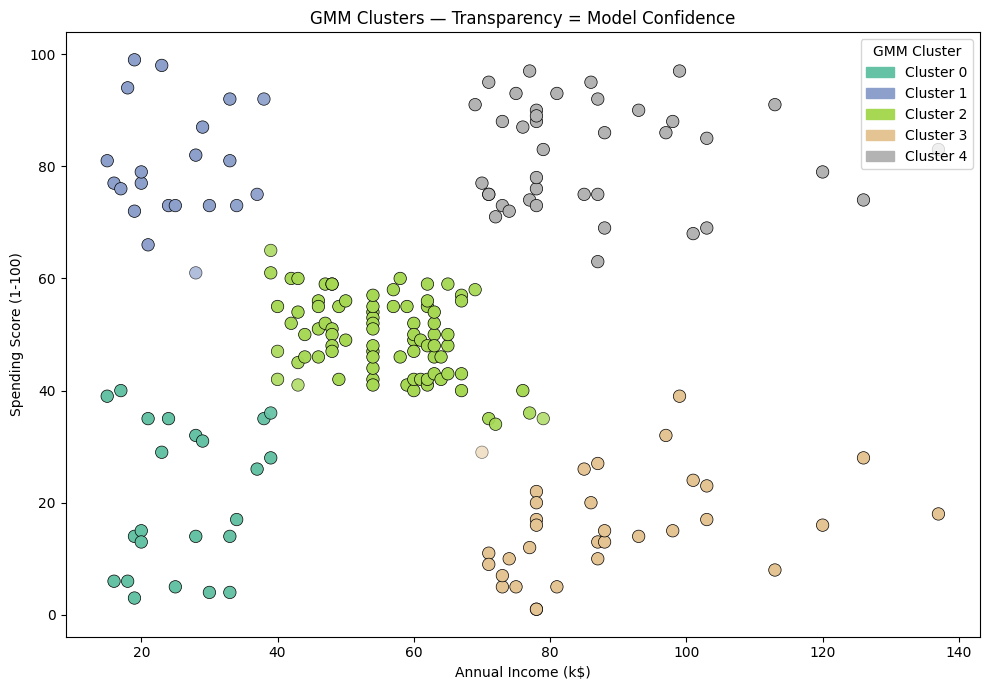

In [10]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['GMM_Cluster'],
    cmap='Set2',
    alpha=df['max_prob'],
    s=80,
    edgecolor='black',
    linewidth=0.5,
)

cmap = plt.cm.Set2
handles = [
    mpatches.Patch(color=cmap(i / 4), label=f'Cluster {i}')
    for i in range(5)
]
plt.legend(handles=handles, title='GMM Cluster', loc='upper right')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('GMM Clusters — Transparency = Model Confidence')
plt.tight_layout()


### GMM — Findings

The probability distribution reveals that **GMM agrees strongly with K-Means** for most customers:

- **~75% of customers** are assigned to their cluster with **>99% confidence**
- **Median maximum probability** is 0.9996 — extremely high confidence overall
- Only a **small minority** of customers (max_prob < 0.7) fall in **borderline regions** between clusters

The customer with the lowest confidence (`max_prob ≈ 0.50`) is split nearly 50/50 between two adjacent clusters. K-Means would force this customer into a definitive bucket; GMM honestly reflects the ambiguity.

**Visual confirmation:** in the transparency plot, faded points appear in the geometric boundaries between clusters — exactly where uncertainty is expected to live.

**Business implication:** customers in the low-confidence region should receive **individual analysis** rather than blanket cluster-based marketing, while the high-confidence majority can be safely targeted via cluster strategy.

## DBSCAN — Density-Based Clustering

DBSCAN takes a fundamentally different approach: instead of asking *"which K minimizes inertia?"*, it asks *"where are the dense regions?"*. It discovers clusters by connecting points that lie within a small distance (`eps`) of at least `min_samples` neighbors.

Key advantages:
- **No need to specify the number of clusters** — DBSCAN discovers it
- **Detects outliers** automatically (labeled as `-1`)
- **Handles arbitrary cluster shapes** — not restricted to spherical groups

Two hyperparameters to tune:
- `eps`: maximum distance to consider two points neighbors
- `min_samples`: minimum number of neighbors to form a dense region (a "core point")

In [11]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled_partial)

df['DBSCAN_Cluster'] = labels_dbscan

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers = (labels_dbscan == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Outliers: {n_outliers}")


Clusters found: 7
Outliers: 35


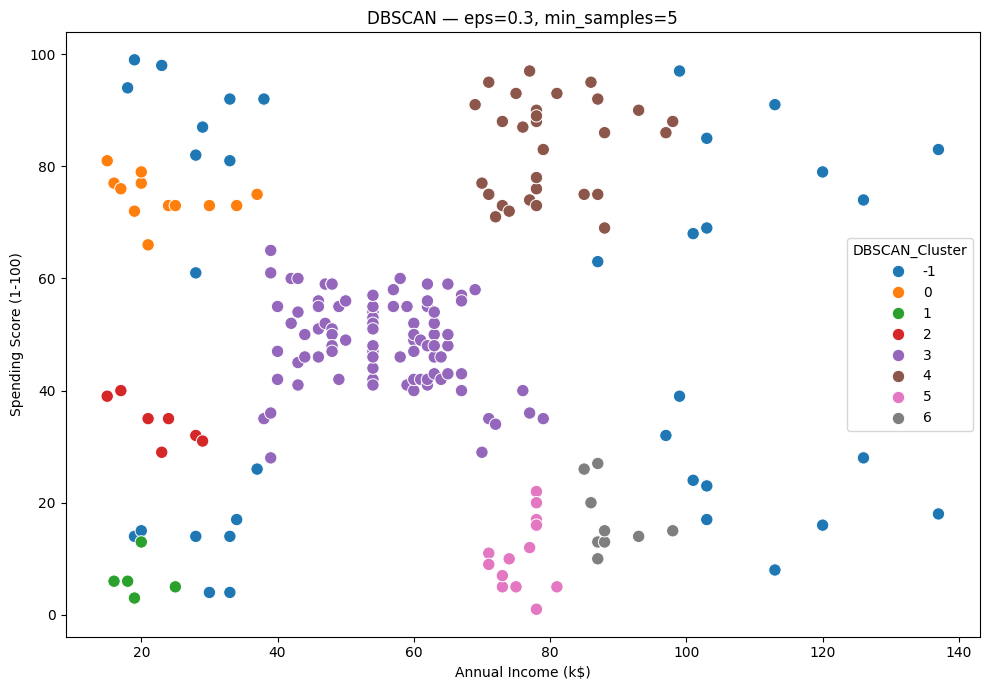

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='DBSCAN_Cluster', palette='tab10', s=80,
)
plt.title('DBSCAN — eps=0.3, min_samples=5')
plt.tight_layout()


### Tuning `eps`

The initial run with `eps=0.3` produced 7 clusters and 35 outliers (too fragmented ). Sweeping `eps` over a range of values to find the sweet spot.

In [13]:
print(f"{'eps':>4}  {'clusters':>10}  {'outliers':>10}")
for eps in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled_partial)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = (labels == -1).sum()
    print(f"{eps:>4.1f}  {n_clusters:>10}  {n_outliers:>10}")


 eps    clusters    outliers
 0.2           7          77
 0.3           7          35
 0.4           4          15
 0.5           2           8
 0.6           1           5
 0.7           1           0


**Sweet spot at `eps=0.4`:** 4 clusters with 15 outliers (~7.5% of customers). Retraining the final model with this value.

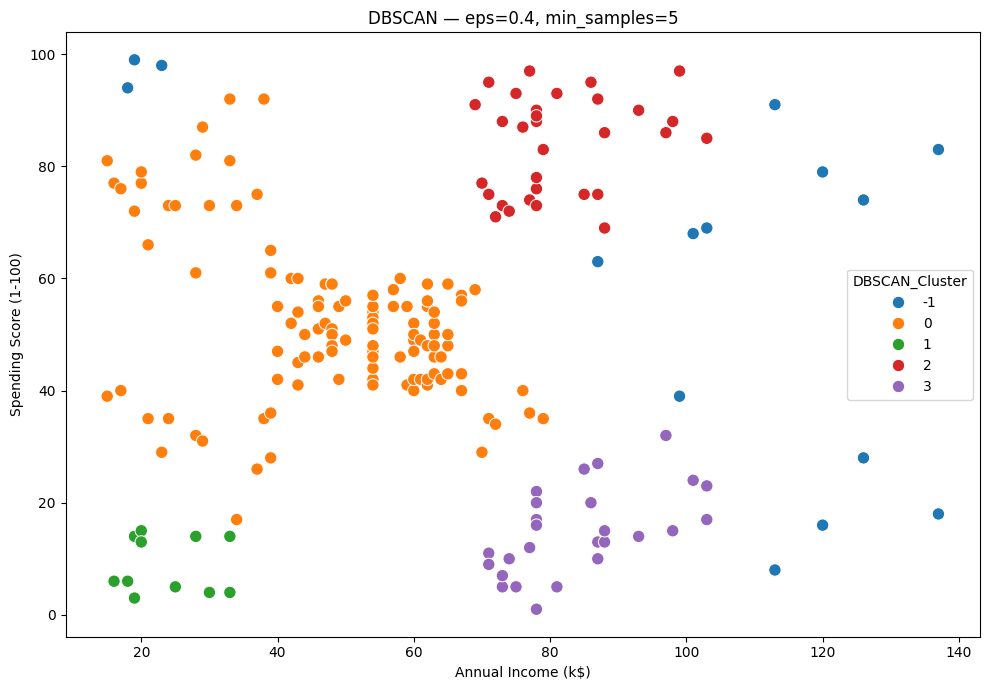

In [14]:
dbscan = DBSCAN(eps=0.4, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled_partial)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='DBSCAN_Cluster', palette='tab10', s=80,
)
plt.title('DBSCAN — eps=0.4, min_samples=5')
plt.tight_layout()


### DBSCAN — Findings

DBSCAN identified only **4 natural clusters** plus **15 outliers**, suggesting that the central "Average" cluster from K-Means may not be a structurally distinct segment in terms of density. The four clusters DBSCAN found correspond roughly to the **four corners** of the Income × Spending plane (Conservative, Impulsive, Target, Careful), with the central region being either absorbed into adjacent clusters or flagged as outliers.

This is a methodologically important finding: **the "correct" number of clusters depends on what the algorithm is looking for**. K-Means assumes spherical, similarly-sized clusters and partitions the entire dataset. DBSCAN looks for dense regions and refuses to force isolated points into a group.

**The 15 outliers** represent customers that don't follow typical spending/income patterns and may warrant **individual analysis** rather than being assigned to a generic segment.

## PCA — Principal Component Analysis

PCA is a **dimensionality reduction** technique that transforms `N` features into `K` new features (called *principal components*) while preserving the **maximum variance** in the data.

It answers a question raised earlier: *"How do we visualize clusters when more than 2 features matter?"*

PCA works by:
1. Finding the direction in the feature space where the data **varies the most** → that becomes `PC1`
2. Finding the next direction, **orthogonal to PC1**, with the next-most variance → that becomes `PC2`
3. Repeating for as many components as requested

Each principal component is a **linear combination** of the original features.

In this section, PCA is applied to all 4 features (`Gender`, `Age`, `Annual Income`, `Spending Score`) to produce a 2D visualization of the full dataset.

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance per component: {pca.explained_variance_ratio_}")
print(f"Total variance preserved by PC1 + PC2: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance per component: [0.33690046 0.26230645]
Total variance preserved by PC1 + PC2: 59.92%


The two principal components together preserve a fraction of the total variance in the 4D space. Now training K-Means on the **full 4-feature** dataset and visualizing the result through the PCA projection — so we can see what the clusters look like when *all* features are considered.

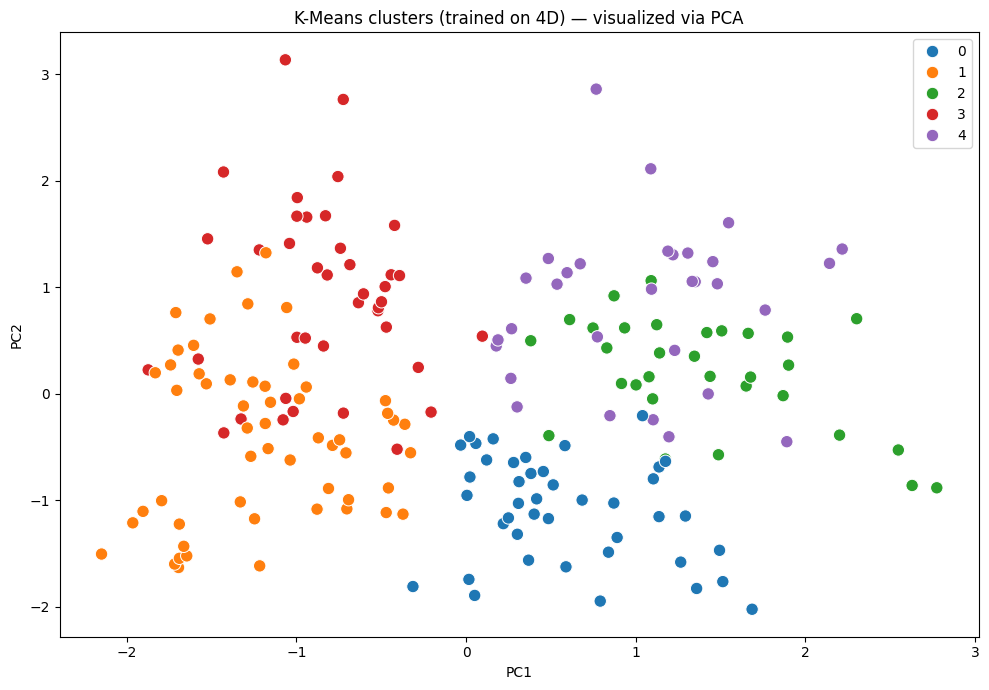

In [16]:
kmeans_4d = KMeans(n_clusters=5, random_state=9, n_init=10)
labels_4d = kmeans_4d.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=labels_4d, palette='tab10', s=80,
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means clusters (trained on 4D) — visualized via PCA')
plt.tight_layout()

### PCA — Findings

The PCA projection lets us visualize all 4 features at once in 2D. Notice that PC1 and PC2 are **synthetic axes** — they don't directly correspond to Income or Spending, but rather to the directions in feature space where the data varies the most.

In this 4D K-Means view, clusters may look **less clean** than the original 2-feature plot. That's expected: including `Age` and `Gender` adds noise without adding much real cluster structure (which is why we chose 2 features for the production model in `02_clustering.ipynb`).

The PCA visualization validates that decision visually — fewer clean separations means the additional dimensions are dilluting the natural structure rather than enhancing it.

## Method Comparison

| Aspect | K-Means | GMM | DBSCAN |
|---|---|---|---|
| Number of clusters | Pre-defined (K=5) | Pre-defined (K=5) | **Discovered automatically (4)** |
| Cluster shape | Spherical | Elliptical (Gaussian) | Arbitrary (density-based) |
| Cluster membership | Hard (definitive) | **Soft (probabilistic)** | Hard (with outlier label) |
| Outlier detection | ❌ Forces every point | ⚠ Implicit (via low confidence) | ✅ **Explicit (label = -1)** |
| Hyperparameter complexity | 1 (`n_clusters`) | 1 (`n_components`) | 2 (`eps`, `min_samples`) |
| Sensitivity to scaling | High (uses distance) | High (uses distance) | High (uses distance) |
| Best use case | Well-separated, equally-sized clusters | Clusters with different shapes or overlap | Arbitrary shapes + outlier identification |

### Which method "wins" for this dataset?

- **For business segmentation** (the original goal): **K-Means with K=5** remains the production model — it produces 5 interpretable segments aligned with business strategy.
- **For confidence/risk analysis**: **GMM** adds value by flagging borderline customers who deserve individual analysis.
- **For outlier detection**: **DBSCAN** is the natural choice — it identified 15 customers (~7.5%) who don't follow typical patterns and could be opportunities or anomalies.

The three methods are **complementary**, not competing — each answers a different business question.

## Conclusions

This notebook expanded the customer segmentation analysis beyond K-Means by exploring three additional techniques and using them to **validate, enrich, and challenge** the original K-Means model.

### Key Takeaways

- **GMM validated the K-Means clustering** by agreeing with >99% confidence for 75% of customers, confirming that the cluster boundaries are statistically robust — not artifacts of the algorithm.
- **GMM also surfaced borderline customers** (max_prob < 0.7) who sit between two clusters and may deserve individual treatment.
- **DBSCAN told a different story**: it discovered **only 4 natural clusters** plus 15 outliers, suggesting that the "Average" center isn't structurally distinct in terms of density — only because K-Means was forced to use K=5 did it appear as a separate group.
- **PCA confirmed the feature selection decision**: visualizing K-Means trained on all 4 features showed less clean separation than the 2-feature plot, validating that `Age` and `Gender` add noise rather than information for this clustering task.

### Methodological Insight

The three methods don't compete — they **answer different questions**. K-Means partitions a customer base into actionable segments. GMM quantifies confidence in each assignment. DBSCAN identifies atypical customers worth investigating individually.

A robust segmentation strategy uses **all three**: K-Means for the marketing playbook, GMM for risk-aware targeting, and DBSCAN for spotting outliers and opportunities.

### Next Steps

- Refactor reusable code from these notebooks into the `src/` modules (`preprocessing.py`, `clustering.py`, `evaluation.py`, `visualization.py`)
- Build an orchestrator `main.py` that runs the end-to-end pipeline
- Update the project `README.md` with results, key figures, and findings